# Real-time simulation of the Schwinger model

Working in the Fock basis, integrate the Schroedinger equation of a colliding particle-antiparticle pair.

In [4]:
import sys
import os
import logging
import time
import numpy as np
import scipy
import h5py
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.experimental.sparse as jsparse
from jax.experimental.sparse import BCOO
from qiskit.quantum_info import SparsePauliOp
from qft_ntrunc.staggered_fermion_1d.fermion import *
from qft_ntrunc.staggered_fermion_1d.schwinger import *

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.99'
jax.config.update('jax_enable_x64', True)

logging.basicConfig(level=logging.INFO)

In [2]:
num_sites = 12
half_lat = num_sites // 2
hdim = 2 ** num_sites
mass = 1.
lsp = 0.5
mu = mass * lsp
l0 = 0

In [3]:
fock_indices, position_indices = get_basis_indices(12)

In [6]:
get_h_free(12, fock_indices, 1.)

array([ 0.        ,  2.82842712,  2.73708922,  2.53224755,  2.41421356,
        2.53224755,  2.73708922,  2.73708922,  2.64575131,  2.44090964,
        2.32287566,  2.44090964,  2.64575131,  5.47417844,  5.26933677,
        5.17799886,  5.15130278,  5.05996487,  4.85512321,  5.26933677,
        5.17799886,  4.9731572 ,  4.85512321,  5.47417844,  5.38284053,
        5.17799886,  5.05996487,  5.17799886,  2.53224755,  2.44090964,
        2.23606798,  2.11803399,  2.23606798,  2.44090964,  5.26933677,
        5.0644951 ,  4.9731572 ,  4.94646111,  4.85512321,  4.65028154,
        5.0644951 ,  4.9731572 ,  4.76831553,  4.65028154,  5.26933677,
        5.17799886,  4.9731572 ,  4.85512321,  4.9731572 ,  5.17799886,
        4.9731572 ,  4.88181929,  4.85512321,  4.7637853 ,  4.55894363,
        4.9731572 ,  4.88181929,  4.67697762,  4.55894363,  5.17799886,
        5.08666096,  4.88181929,  4.7637853 ,  4.88181929,  7.71024641,
        7.59221242,  7.38737076,  7.29603285,  7.71024641,  7.50

In [ ]:
basis_change_matrix = get_basis_change_matrix()
get_h_elec(12, position_indices, )

## Hamiltonian


In [3]:
filename = f'/data/iiyama/strings_eventgen/schwinger_{num_sites}sites_mu_{mu:.1f}_l0_{l0}_new.h5'
if os.path.exists(filename):
    with h5py.File(filename, 'r') as source:
        fock_indices = source['fock_indices'][:]
        pos_indices = source['pos_indices'][:]
        fermi_num_data = source['fermi_num_data'][:]
        fermi_num_indices = source['fermi_num_indices'][:]
        basis_change_mat = source['basis_change_mat'][:]
        h_free = source['h_free'][:]
        h_elec_data = source['h_elec'][:]
        h_elec_indices = source['h_elec_indices'][:]

    subdim = fock_indices.shape[0]
    fermi_num = BCOO((fermi_num_data, fermi_num_indices), shape=(num_sites, subdim, subdim))
    h_elec = BCOO((h_elec_data, h_elec_indices), shape=(subdim, subdim))
else:
    start = time.time()
    fock_indices, pos_indices, fermi_num, basis_change_mat, h_free, h_elec = setup(num_sites, mu, l0)
    print(time.time() - start, 'seconds passed')

    subdim = fock_indices.shape[0]

    with h5py.File(filename, 'w') as out:
        out.create_dataset('fock_indices', data=fock_indices)
        out.create_dataset('pos_indices', data=pos_indices)
        out.create_dataset('fermi_num_data', data=fermi_num.data)
        out.create_dataset('fermi_num_indices', data=fermi_num.indices)
        out.create_dataset('basis_change_mat', data=basis_change_mat)
        out.create_dataset('h_free', data=h_free)
        out.create_dataset('h_elec_data', data=h_elec.data)
        out.create_dataset('h_elec_indices', data=h_elec.indices)


Identifying Fock-space and position-space physical state indices


Free Hamiltonian
Constructing position-space number operators
Computing basis change matrix
Computing the electric Hamiltonian
14.94158673286438 seconds passed


## Time evolution

In [6]:
tlist = np.linspace(-1., 1., 100)

@jax.jit
def dpsidt(y, t, h_free, h_elec, width):
    dy = h_free * y
    dy += jnp.exp(-jnp.square(t / width)) * (h_elec @ y)
    return -1.j * dy

In [7]:
initial_state_idx = np.sum(np.array([0, 1] + [0] * (num_sites - 3) + [1]) * (1 << np.arange(num_sites)))
initial_state_subidx = np.nonzero(fock_indices == initial_state_idx)[0][0]
initial_state = np.zeros(subdim, dtype=np.complex128)
initial_state[initial_state_subidx] = 1.

In [10]:
num_exc = np.sum((fock_indices[:, None] >> np.arange(num_sites)[None, :]) % 2, axis=1)
trunc_4 = np.nonzero(num_exc > 4)[0]
trunc_6 = np.nonzero(num_exc > 6)[0]
h_elec_trunc_4 = BCOO((jnp.array(h_elec.data), jnp.array(h_elec.indices)), shape=h_elec.shape)
h_elec_trunc_4[trunc_4] = 0.
h_elec_trunc_4[:, trunc_4] = 0.
h_elec_trunc_6 = BCOO((jnp.array(h_elec.data), jnp.array(h_elec.indices)), shape=h_elec.shape)
h_elec_trunc_6[trunc_6] = 0.
h_elec_trunc_6[:, trunc_6] = 0.

TypeError: Only integer scalar arrays can be converted to a scalar index.

In [ ]:
coupling_j = 0.5
width = 0.3
yvals = odeint(dpsidt, initial_state, tlist, h_free, coupling_j * h_elec, width)
yvals_trunc_4 = odeint(dpsidt, initial_state, tlist, h_free, coupling_j * h_elec_trunc_4, width)
yvals_trunc_6 = odeint(dpsidt, initial_state, tlist, h_free, coupling_j * h_elec_trunc_6, width)

Text(0, 0.5, '$\\langle n \\rangle$')

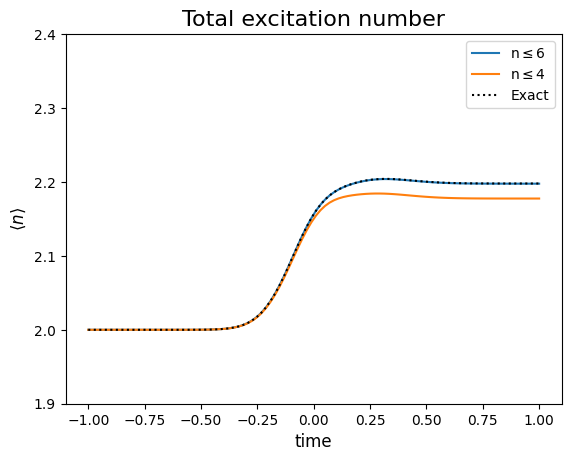

In [ ]:
probs = np.square(np.abs(yvals))
probs_trunc_4 = np.square(np.abs(yvals_trunc_4))
probs_trunc_6 = np.square(np.abs(yvals_trunc_6))
nvals = np.sum(probs * num_exc[None, :], axis=1)
nvals_trunc_4 = np.sum(probs_trunc_4 * num_exc[None, :], axis=1)
nvals_trunc_6 = np.sum(probs_trunc_6 * num_exc[None, :], axis=1)
plt.plot(tlist, nvals_trunc_6, label=fr'n$\leq$6')
plt.plot(tlist, nvals_trunc_4, label=fr'n$\leq$4')
plt.plot(tlist, nvals, color='k', linestyle=':', label='Exact')
plt.legend()
plt.ylim(1.9, 2.4)
plt.title('Total excitation number', fontsize=16)
plt.xlabel('time', fontsize=12)
plt.ylabel(r'$\langle n \rangle$', fontsize=12)

Text(0, 0.5, 'probability')

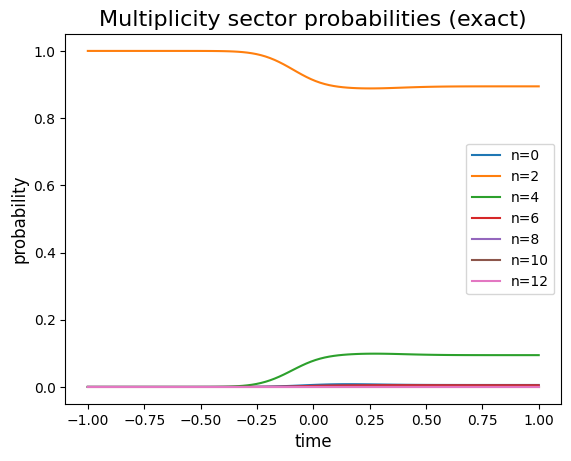

In [ ]:
mult_sectors = [np.nonzero(num_exc == n)[0] for n in range(0, 14, 2)]
sector_p = np.array([np.sum(probs[:, s], axis=1) for s in mult_sectors]).T
plt.plot(tlist, sector_p, label=[f'n={n}' for n in range(0, 14, 2)])
plt.legend()
plt.title('Multiplicity sector probabilities (exact)', fontsize=16)
plt.xlabel('time', fontsize=12)
plt.ylabel('probability', fontsize=12)

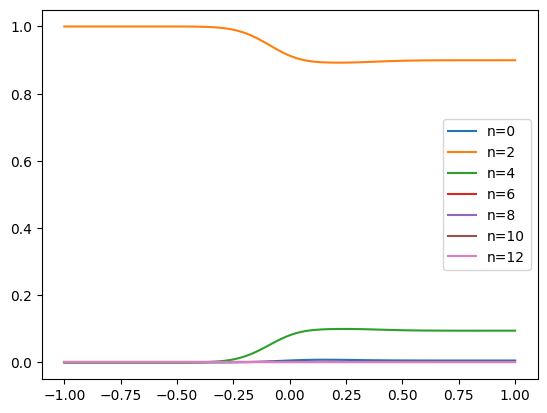

In [ ]:
sector_p_trunc = np.array([np.sum(probs_trunc[:, s], axis=1) for s in mult_sectors]).T
plt.plot(tlist, sector_p_trunc, label=[f'n={n}' for n in range(0, 14, 2)])
plt.legend();

In [ ]:
coupling_js = np.linspace(0., 1., 20)
width = 0.3
yvals = []
yvals_trunc_4 = []
yvals_trunc_6 = []
tends = np.array([-1., 1.])
for jval in coupling_js:
    yvals.append(odeint(dpsidt, initial_state, tends, h_free, jval * h_elec, width))
    yvals_trunc_4.append(odeint(dpsidt, initial_state, tends, h_free, jval * h_elec_trunc_4, width))
    yvals_trunc_6.append(odeint(dpsidt, initial_state, tends, h_free, jval * h_elec_trunc_6, width))

yvals = np.array(yvals)
yvals_trunc_4 = np.array(yvals_trunc_4)
yvals_trunc_6 = np.array(yvals_trunc_6)

In [ ]:
pass_prob = np.square(np.abs(yvals[:, 1, initial_state_subidx]))
pass_prob_trunc_4 = np.square(np.abs(yvals_trunc_4[:, 1, initial_state_subidx]))
pass_prob_trunc_6 = np.square(np.abs(yvals_trunc_6[:, 1, initial_state_subidx]))

Text(0, 0.5, '$|\\langle init | final \\rangle|^2$')

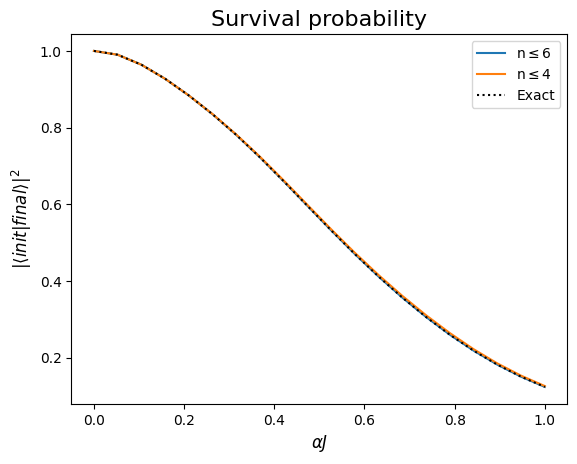

In [ ]:
plt.plot(coupling_js, pass_prob_trunc_6, label=r'n$\leq$6')
plt.plot(coupling_js, pass_prob_trunc_4, label=r'n$\leq$4')
plt.plot(coupling_js, pass_prob, color='k', linestyle=':', label='Exact')
plt.legend()
plt.title('Survival probability', fontsize=16)
plt.xlabel(r'$\alpha J$', fontsize=12)
plt.ylabel(r'$|\langle init | final \rangle|^2$', fontsize=12)

In [ ]:
final_states = np.argsort(np.square(np.abs(yvals[-1, 1])))[::-1]
final_state_nums = np.sum((fock_indices[final_states, None] >> np.arange(num_sites)[None, :]) % 2, axis=1)

In [ ]:
np.nonzero(final_state_nums == 6)[0]

array([ 93,  94, 109, 117, 122, 153, 156, 179, 180, 181, 182, 183, 184,
       185, 186, 199, 208, 209, 212, 213, 216, 217, 218, 219, 226, 227,
       232, 233, 234, 235, 236, 237, 238, 241, 242, 243, 244, 249, 250,
       251, 252, 257, 258, 259, 260, 263, 264, 265, 266, 267, 268, 269,
       270, 271, 272, 273, 274, 275, 276, 279, 280, 281, 282, 283, 288,
       289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301,
       304, 305, 306, 307, 310, 311, 312, 313, 316, 317, 320, 321, 322,
       323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
       340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352,
       353, 354, 355, 358, 359, 360, 361, 364, 365, 366, 367, 368, 371,
       372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 389, 390,
       391, 392, 393, 394, 395, 396, 399, 400, 401, 402, 403, 404, 405,
       406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 419, 420,
       421, 422, 423, 424, 425, 426, 429, 430, 431, 432, 433, 43

In [ ]:
final_states[9]

217

Text(0, 0.5, '$|\\langle n=4 state|init\\rangle|^2$')

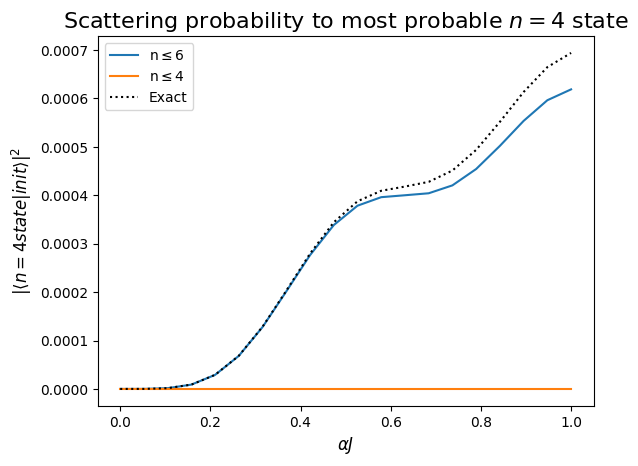

In [ ]:
plt.plot(coupling_js, np.square(np.abs(yvals_trunc_6[:, 1, final_states[9]])), label=r'n$\leq$6')
plt.plot(coupling_js, np.square(np.abs(yvals_trunc_4[:, 1, final_states[9]])), label=r'n$\leq$4')
plt.plot(coupling_js, np.square(np.abs(yvals[:, 1, final_states[9]])), color='k', linestyle=':', label='Exact')
plt.legend()
plt.title('Scattering probability to most probable $n=4$ state', fontsize=16)
plt.xlabel(r'$\alpha J$', fontsize=12)
plt.ylabel(r'$|\langle n=4 state|init\rangle|^2$', fontsize=12)

Text(0, 0.5, '$|\\langle n=6 state|init\\rangle|^2$')

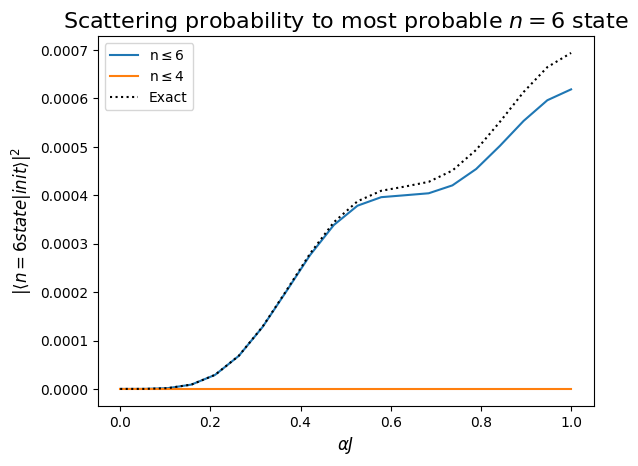

In [ ]:
plt.plot(coupling_js, np.square(np.abs(yvals_trunc_6[:, 1, final_states[93]])), label=r'n$\leq$6')
plt.plot(coupling_js, np.square(np.abs(yvals_trunc_4[:, 1, final_states[93]])), label=r'n$\leq$4')
plt.plot(coupling_js, np.square(np.abs(yvals[:, 1, final_states[93]])), color='k', linestyle=':', label='Exact')
plt.legend()
plt.title('Scattering probability to most probable $n=6$ state', fontsize=16)
plt.xlabel(r'$\alpha J$', fontsize=12)
plt.ylabel(r'$|\langle n=6 state|init\rangle|^2$', fontsize=12)

In [ ]:
(np.array(fock_indices[[212, 1, 2, 217]])[:, None] >> np.arange(num_sites)[None, :]) % 2

array([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0]])

In [ ]:
get_rapidity(num_sites, mu)

array([-1.44363548, -1.3169579 , -0.88137359,  0.        ,  0.88137359,
        1.3169579 ])

In [ ]:
final_state =
scat_prob = np.square(np.abs(yvals[:, 1, ]))

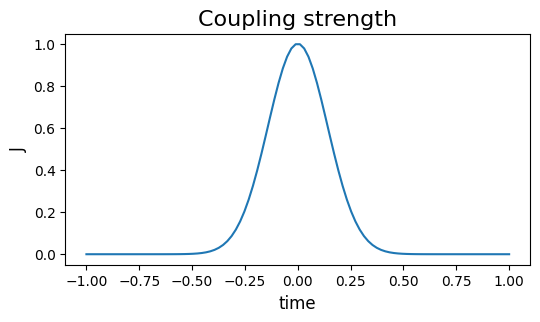

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(tlist, np.exp(-np.square(tlist / 0.2)))
ax.set_title('Coupling strength', fontsize=16)
ax.set_xlabel('time', fontsize=12)
ax.set_ylabel('J', fontsize=12);

## Checking subspace dimension scaling

In [ ]:
ns = np.arange(2, 24, 2)
subdims = []
for n in ns:
    subdim = np.prod(np.arange(n // 2, n) + 1) / np.prod(np.arange(n // 2) + 1)
    subdims.append(subdim)
subdims = np.array(subdims)

In [ ]:
print(ns[5], subdims[5])
print(ns[7], subdims[7])

12 924.0
16 12870.0


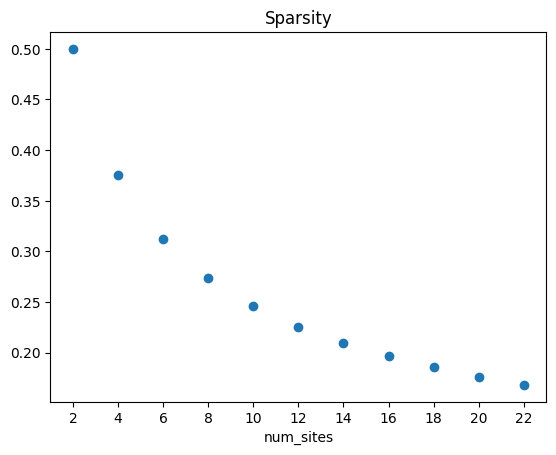

In [ ]:
plt.scatter(ns, subdims / (2 ** ns))
plt.title('Sparsity')
plt.xlabel('num_sites')
plt.xticks(ns, labels=[f'{n}' for n in ns]);

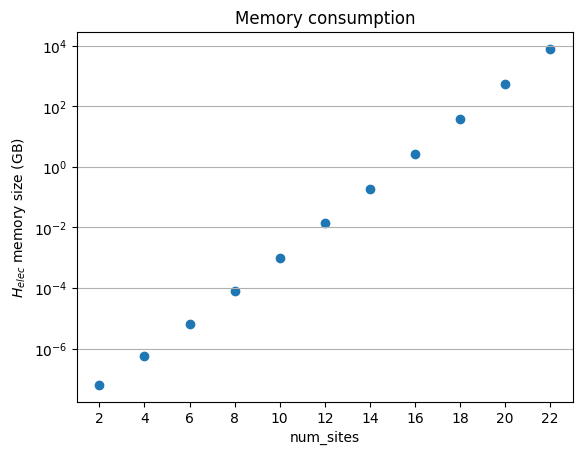

In [ ]:
plt.scatter(ns, np.square(subdims) * 16 * 1.e-9)
plt.title('Memory consumption')
plt.xlabel('num_sites')
plt.ylabel('$H_{elec}$ memory size (GB)')
plt.yscale('log')
plt.grid(axis='y')
plt.xticks(ns, labels=[f'{n}' for n in ns]);